## imports and loading the data


In [7]:
from pandas.util import version
from src.data_loader import load_data
import src.NextGen_Vega_Strategy as nextgen
import numpy as np
from src.backtester import VIXBacktester as bt 

vega_Data  =  load_data('data/Vega_Data.xlsx')

vega_Data = vega_Data.set_index('Date')
vega_Data = vega_Data.loc['2011-10-04':'2026-03-31']   #slicing to cut out faulty data. vix values stay at 25.25 after thius date 

In [8]:
backtester = bt(initial_portfolio= 1000)
# 2. Calculate daily returns and strategy signals on the DataFrame
backtester.load_values(vega_Data)
# 3. Run and display the resulting DataFrame
backtester.run_simulation(vega_Data)

display (vega_Data)



,ID,SVXY Open,SVXY Close,VXX Open,VXX Close,VIX,SPX,ALSI,ZAR,SVXY_Returns,VXX_Returns,Signal,Strategy_Returns,Portfolio_Value
Date,,,,,,,,,,,,,,
2011-10-04,102011,NaN,NaN,59658.24,54113.4848,40.82,1918.39,3445.14,8.10505,NaN,NaN,Short,NaN,1000.000000
2011-10-05,102011,10.8825,11.3475,53411.84,51466.2400,37.81,1953.67,3479.41,7.98000,NaN,-0.048920,Short,NaN,1000.000000
2011-10-06,102011,11.3575,11.5825,51630.08,50565.1200,36.27,1989.61,3529.04,7.93805,0.020709,-0.017509,Short,0.020709,1020.709407
2011-10-07,102011,11.7962,11.6725,49643.52,51425.2800,36.20,1973.42,3571.08,7.99500,0.007770,0.017011,Short,0.007770,1028.640670
2011-10-10,102011,11.8750,12.1500,49408.00,47728.6400,33.02,2040.76,3656.79,7.84630,0.040908,-0.071884,Short,0.040908,1070.720423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,32026,46.9800,47.0200,32.95,33.2100,25.33,14700.18,21764.90,16.96225,0.015770,-0.018617,Short,0.015770,26737.453605
2026-03-26,32026,46.4100,45.1900,33.87,35.4900,27.44,14444.36,21485.88,17.11765,-0.038920,0.068654,Short,-0.038920,25696.842374
2026-03-27,32026,44.8200,43.4400,36.07,38.2300,31.05,14203.24,21282.30,17.10381,-0.038725,0.077205,Short,-0.038725,24701.722344


## Plotting the Portfolio Value over Time

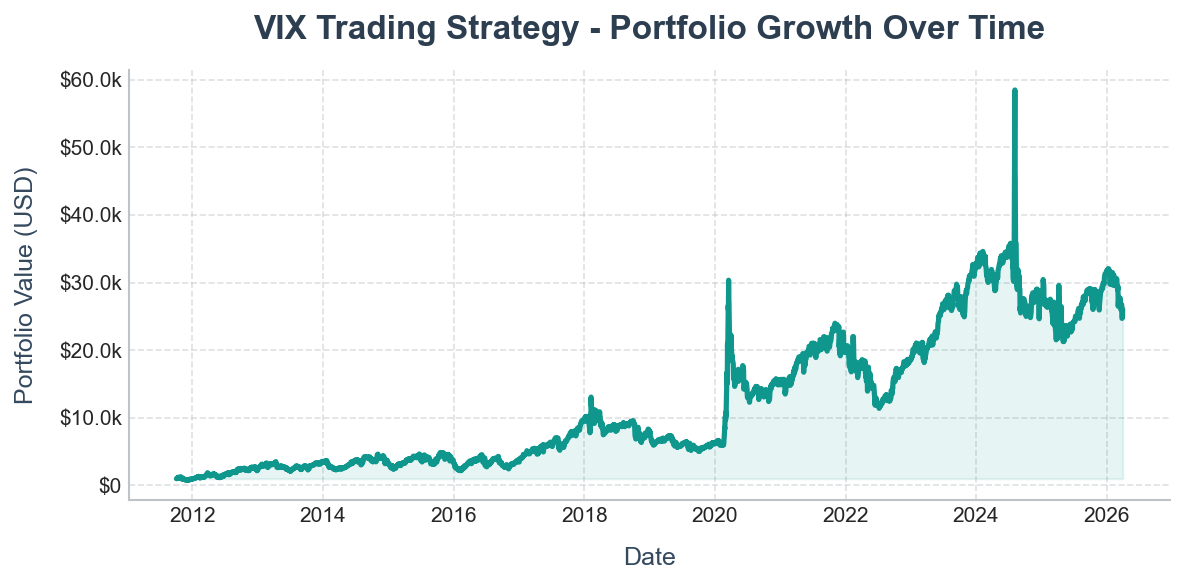

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set modern styling
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

# Plot the portfolio value curve
ax.plot(vega_Data.index, vega_Data['Portfolio_Value'], color='#0f978e', linewidth=2.5, label='Strategy Portfolio Value')
ax.fill_between(vega_Data.index, vega_Data['Portfolio_Value'], vega_Data['Portfolio_Value'].iloc[0], color='#0f978e', alpha=0.1)

# Add titles and labels
ax.set_title('VIX Trading Strategy - Portfolio Growth Over Time', fontsize=16, fontweight='bold', pad=15, color='#2c3e50')
ax.set_xlabel('Date', fontsize=12, labelpad=10, color='#34495e')
ax.set_ylabel('Portfolio Value (USD)', fontsize=12, labelpad=10, color='#34495e')

# Dynamic currency formatter to handle k/M/B suffixes
def currency_formatter(x, pos):
    if x >= 1e9:
        return f"${x*1e-9:.1f}B"
    elif x >= 1e6:
        return f"${x*1e-6:.1f}M"
    elif x >= 1e3:
        return f"${x*1e-3:.1f}k"
    else:
        return f"${x:.0f}"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))

# Style grid and axes
ax.grid(True, linestyle='--', alpha=0.5, color='#bdc3c7')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

plt.tight_layout()
plt.show()